# GNSS III Lab: Measuring Tectonic Strain from GNSS Velocities

> **Colab note:** This notebook is designed to run on **Google Colab**. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS166/blob/main/notebooks/03_gnss_strain.ipynb)

## Introduction

In this lab you will use the North America-fixed GNSS velocity field from Kreemer and Young (2022) to calculate and visualize the horizontal strain-rate tensor. You will first complete a guided example in the Pacific Northwest, then apply exactly the same analysis near the northern San Andreas fault system.

Archived data: [Kreemer and Young velocity archive](https://doi.org/10.7910/DVN/BICMWB)  
Course copy: [Kreemer_GPS_table.txt](https://github.com/amtseismo/EPS166/blob/main/datasets/Kreemer_GPS_table.txt)

## Learning objectives

By the end, you will be able to:

- explain why velocity and strain are different quantities
- solve for a local two-dimensional velocity gradient
- calculate and visualize a horizontal strain-rate tensor
- calculate principal strain rates, dilatation, rotation, and the strain measures used in Kreemer and Young (2022)
- compare strain estimates from Cascadia and the northern San Andreas system
- evaluate sensitivity to station geometry and spatial scale

## Notebook Outline:
- [Part I: Load and inspect the velocity table](#part-i-load-and-inspect-the-velocity-table)
- [Part II: Fit and visualize horizontal strain](#part-ii-fit-and-visualize-horizontal-strain)
- [Part III: PNW example](#part-iii-pnw-example)
- [Part IV: Northern San Andreas example](#part-iv-northern-san-andreas-example)
- [Part V: Compare the two tectonic settings](#part-v-compare-the-two-tectonic-settings)
- [Part VI: Sensitivity to station geometry](#part-vi-sensitivity-to-station-geometry)
- [Part VII: Optional extension using more stations](#part-vii-optional-extension-using-more-stations)
- [Synthesis](#synthesis)
- [Summary](#summary)


## Setup

Install the small state-boundary dataset used for the maps, then import the scientific Python packages used in the lab.


In [14]:
%pip install -q bokeh_sampledata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bokeh_sampledata.us_states import data as US_STATES

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
})



Note: you may need to restart the kernel to use updated packages.


## Part I: Load and inspect the velocity table

Read the course copy of the Kreemer and Young velocity table directly from GitHub. The table already has concise column names, so we retain them throughout the notebook.


In [15]:
DATA_URL = (
    "https://github.com/amtseismo/EPS166/"
    "raw/main/datasets/Kreemer_GPS_table.txt"
)

velocity = pd.read_csv(DATA_URL, sep=r"\s+")

print(f"Stations: {len(velocity):,}")
display(velocity.head())


Stations: 3,048


,lon,lat,ve,vn,sdve,sdvn,ve_p,vn_p,stat,source
0,-112.183,33.431,-3.96,1.96,0.18,0.11,2.15,-0.35,59WE,#
1,-114.759,37.595,-3.62,3.11,0.25,0.18,1.03,-1.21,7OAK,#
2,-117.093,34.116,-16.81,15.71,0.18,0.18,1.01,2.20,7ODM,#
3,-113.573,50.016,2.49,2.19,0.36,0.33,-1.77,-1.38,ABCH,#
4,-112.835,49.706,3.14,1.77,0.31,0.28,-1.76,-1.26,ABLT,#


### Dataset columns

The columns used below are `lon`, `lat`, `ve`, `vn`, `sdve`, `sdvn`, and `stat`. The `ve_p` and `vn_p` columns contain modeled postseismic corrections and are not used in this calculation.


In [16]:
numeric_columns = [
    "lon", "lat", "ve", "vn", "sdve", "sdvn"
]

velocity[numeric_columns] = velocity[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce",
)
velocity = velocity.dropna(subset=numeric_columns).copy()

print(f"Usable horizontal velocities: {len(velocity):,}")
display(velocity.head())


Usable horizontal velocities: 3,035


,lon,lat,ve,vn,sdve,sdvn,ve_p,vn_p,stat,source
0,-112.183,33.431,-3.96,1.96,0.18,0.11,2.15,-0.35,59WE,#
1,-114.759,37.595,-3.62,3.11,0.25,0.18,1.03,-1.21,7OAK,#
2,-117.093,34.116,-16.81,15.71,0.18,0.18,1.01,2.20,7ODM,#
3,-113.573,50.016,2.49,2.19,0.36,0.33,-1.77,-1.38,ABCH,#
4,-112.835,49.706,3.14,1.77,0.31,0.28,-1.76,-1.26,ABLT,#


### Confirm units and corrections

The Kreemer archive accompanies a North America-fixed velocity field corrected for modeled postseismic viscoelastic deformation. Confirm from the archive metadata that the selected east and north columns are the corrected velocities rather than the correction terms themselves.

The next cell assumes the velocity columns are in **mm/yr**. Change `VELOCITY_SCALE_TO_M_PER_YR` if the archive reports different units.


In [17]:
VELOCITY_SCALE_TO_M_PER_YR = 1e-3  # mm/yr -> m/yr

print(velocity[["ve", "vn"]].describe())
print("Maximum horizontal speed:", np.hypot(velocity.ve, velocity.vn).max(), "input units/yr")


                ve           vn
count  3035.000000  3035.000000
mean     -7.878079    12.157157
std      10.662725     9.990935
min     -37.540000    -0.250000
25%     -16.180000     4.070000
50%      -4.990000     8.770000
75%       0.000000    19.315000
max      13.020000    38.670000
Maximum horizontal speed: 52.18538205283161 input units/yr


## Map the western velocity field

The arrows are velocities relative to North America. Look for coherent translation, broad turning of the vectors, and sharp spatial gradients.


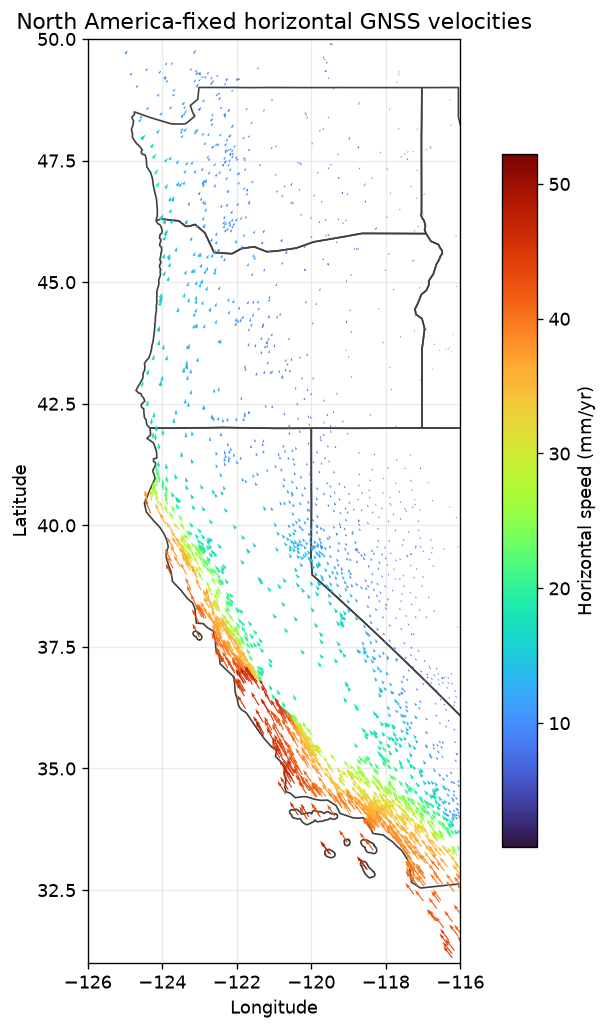

In [18]:
def add_state_outlines(
    ax,
    state_codes=("CA", "OR", "WA", "NV", "ID"),
):
    """
    Add selected U.S. state boundaries to a Matplotlib map.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to draw the state boundaries.
    state_codes : iterable of str, optional
        Two-letter postal codes for the states to plot.
    """
    states = US_STATES

    for code in state_codes:
        state = states[code]

        ax.plot(
            state["lons"],
            state["lats"],
            color="0.25",
            linewidth=1.0,
            zorder=2,
        )


fig, ax = plt.subplots(figsize=(9, 10))

add_state_outlines(ax)

speed = np.hypot(velocity["ve"], velocity["vn"])

q = ax.quiver(
    velocity["lon"],
    velocity["lat"],
    velocity["ve"],
    velocity["vn"],
    speed,
    angles="xy",
    scale_units="xy",
    scale=130,
    cmap="turbo",
    width=0.003,
    zorder=3,
)

ax.set(
    xlim=(-126, -116),
    ylim=(31, 50),
    xlabel="Longitude",
    ylabel="Latitude",
    title="North America-fixed horizontal GNSS velocities",
)

ax.set_aspect(
    1 / np.cos(np.deg2rad(40)),
    adjustable="box",
)

plt.colorbar(
    q,
    ax=ax,
    label="Horizontal speed (mm/yr)",
    shrink=0.75,
)

plt.show()

> **Interpret the velocity field:**
> 1. In which part of the map are velocities largest?
> 2. How does the direction change from southern California to Washington?
> 3. Give one example of two nearby regions that appear to move almost rigidly together.
> 4. Give one example of a region with a strong velocity gradient.
> 5. Why can the broad turning of the vectors not be interpreted directly as strain?

## Part II: Fit and visualize horizontal strain

For local east and north coordinates $(x,y)$, we fit

$$
v_E=t_E-\omega y+\dot\epsilon_{EE}x+\dot\epsilon_{EN}y,
$$

$$
v_N=t_N+\omega x+\dot\epsilon_{EN}x+\dot\epsilon_{NN}y.
$$

The fitted tensor is

$$
\dot{\boldsymbol\epsilon}=
\begin{bmatrix}
\dot\epsilon_{EE} & \dot\epsilon_{EN}\\
\dot\epsilon_{EN} & \dot\epsilon_{NN}
\end{bmatrix}.
$$

The helper functions below report the tensor components, calculate its principal values and the quantities shown in Kreemer and Young's Figure 2, and visualize the relative velocities and principal strain axes.


In [19]:
EARTH_RADIUS_M = 6_371_000.0


def local_xy(lon, lat):
    """
    Convert longitude and latitude to local east and north coordinates.

    Parameters
    ----------
    lon, lat : array-like
        Station longitudes and latitudes in decimal degrees.

    Returns
    -------
    x, y : numpy.ndarray
        East and north coordinates relative to the network centroid,
        in meters.
    lon0, lat0 : float
        Longitude and latitude of the network centroid, in decimal degrees.
    """
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    lon0 = np.mean(lon)
    lat0 = np.mean(lat)

    x = (
        EARTH_RADIUS_M
        * np.cos(np.deg2rad(lat0))
        * np.deg2rad(lon - lon0)
    )
    y = EARTH_RADIUS_M * np.deg2rad(lat - lat0)

    return x, y, lon0, lat0


def fit_horizontal_strain(stations, velocity_scale=1e-3):
    """
    Estimate translation, rotation, and horizontal strain rate.

    Parameters
    ----------
    stations : pandas.DataFrame
        Table containing ``lon``, ``lat``, ``ve``, ``vn``, ``sdve``, and
        ``sdvn``. Velocities and uncertainties must use the same units.
    velocity_scale : float, default=1e-3
        Factor that converts input velocities to meters per year. The
        default converts millimeters per year to meters per year.

    Returns
    -------
    dict
        Model parameters, tensor components, principal strain rates and
        axes, Figure 2 strain measures, predictions, and residuals.

    Raises
    ------
    ValueError
        If the network has fewer than three stations, invalid uncertainty
        values, or rank-deficient station geometry.
    """
    if len(stations) < 3:
        raise ValueError("At least three non-collinear stations are required.")

    x, y, lon0, lat0 = local_xy(stations.lon, stations.lat)
    n_stations = len(stations)

    design = np.zeros((2 * n_stations, 6))
    data = np.zeros(2 * n_stations)
    sigma = np.zeros(2 * n_stations)

    for i in range(n_stations):
        design[2 * i] = [1, 0, -y[i], x[i], y[i], 0]
        design[2 * i + 1] = [0, 1, x[i], 0, x[i], y[i]]
        data[2 * i:2 * i + 2] = [
            stations.iloc[i].ve,
            stations.iloc[i].vn,
        ]
        sigma[2 * i:2 * i + 2] = [
            stations.iloc[i].sdve,
            stations.iloc[i].sdvn,
        ]

    data *= velocity_scale
    sigma *= velocity_scale

    positive_sigma = sigma[sigma > 0]
    if positive_sigma.size == 0:
        raise ValueError("At least one positive uncertainty is required.")
    sigma = np.where(sigma > 0, sigma, np.nanmedian(positive_sigma))

    weighted_design = design / sigma[:, None]
    weighted_data = data / sigma
    model, _, rank, singular_values = np.linalg.lstsq(
        weighted_design,
        weighted_data,
        rcond=None,
    )

    if rank < 6:
        raise ValueError(
            "Station geometry does not constrain all six model parameters."
        )

    predicted = design @ model
    residual = data - predicted
    strain_tensor = np.array([
        [model[3], model[4]],
        [model[4], model[5]],
    ])

    principal, axes = np.linalg.eigh(strain_tensor)
    order = np.argsort(principal)[::-1]
    principal = principal[order]
    axes = axes[:, order]

    # Counterclockwise from east, matching the convention in the lecture.
    azimuth = (
        np.degrees(np.arctan2(axes[1], axes[0])) + 360
    ) % 180

    tensor_magnitude = np.sqrt(np.sum(principal**2))
    kreemer_shear = (
        min(abs(principal[0]), abs(principal[1]))
        if principal[0] * principal[1] < 0
        else 0.0
    )

    return {
        "centroid_lon": lon0,
        "centroid_lat": lat0,
        "x_m": x,
        "y_m": y,
        "translation_e_mm_yr": model[0] * 1e3,
        "translation_n_mm_yr": model[1] * 1e3,
        "rotation_nrad_yr": model[2] * 1e9,
        "rotation_direction": (
            "counterclockwise" if model[2] > 0 else "clockwise"
        ),
        "eps_ee_nstrain_yr": model[3] * 1e9,
        "eps_en_nstrain_yr": model[4] * 1e9,
        "eps_nn_nstrain_yr": model[5] * 1e9,
        "e1_nstrain_yr": principal[0] * 1e9,
        "e2_nstrain_yr": principal[1] * 1e9,
        "e1_azimuth_deg": azimuth[0],
        "e2_azimuth_deg": azimuth[1],
        "tensor_magnitude_nstrain_yr": tensor_magnitude * 1e9,
        "dilatation_nstrain_yr": principal.sum() * 1e9,
        "kreemer_shear_nstrain_yr": kreemer_shear * 1e9,
        "max_engineering_shear_nstrain_yr": (
            principal[0] - principal[1]
        ) * 1e9,
        "condition_number": singular_values[0] / singular_values[-1],
        "rms_residual_mm_yr": np.sqrt(np.mean(residual**2)) * 1e3,
        "strain_tensor_per_yr": strain_tensor,
        "principal_axes": axes,
        "model": model,
        "predicted_m_yr": predicted.reshape(-1, 2),
        "residual_m_yr": residual.reshape(-1, 2),
    }


def strain_summary_table(result):
    """
    Create a student-facing table of strain and rotation results.

    Parameters
    ----------
    result : dict
        Dictionary returned by ``fit_horizontal_strain``.

    Returns
    -------
    pandas.DataFrame
        Quantitative tensor, principal-axis, and Figure 2 results.
    """
    rows = [
        (r"$\dot\epsilon_{EE}$", result["eps_ee_nstrain_yr"], "nstrain/yr"),
        (r"$\dot\epsilon_{EN}$", result["eps_en_nstrain_yr"], "nstrain/yr"),
        (r"$\dot\epsilon_{NN}$", result["eps_nn_nstrain_yr"], "nstrain/yr"),
        (r"Rotation, $\omega$", result["rotation_nrad_yr"], "nrad/yr"),
        (r"Maximum principal rate, $\dot\epsilon_1$", result["e1_nstrain_yr"], "nstrain/yr"),
        (r"$\dot\epsilon_1$ azimuth", result["e1_azimuth_deg"], "deg CCW from east"),
        (r"Minimum principal rate, $\dot\epsilon_2$", result["e2_nstrain_yr"], "nstrain/yr"),
        (r"$\dot\epsilon_2$ azimuth", result["e2_azimuth_deg"], "deg CCW from east"),
        ("Tensor magnitude (Fig. 2a)", result["tensor_magnitude_nstrain_yr"], "nstrain/yr"),
        ("Dilatation (Fig. 2b)", result["dilatation_nstrain_yr"], "nstrain/yr"),
        ("Kreemer shear rate (Fig. 2c)", result["kreemer_shear_nstrain_yr"], "nstrain/yr"),
    ]

    return pd.DataFrame(
        rows,
        columns=["quantity", "value", "units"],
    ).set_index("quantity").round(1)


def strain_tensor_table(result):
    """
    Format the horizontal strain-rate tensor as a labeled 2 by 2 table.

    Parameters
    ----------
    result : dict
        Dictionary returned by ``fit_horizontal_strain``.

    Returns
    -------
    pandas.DataFrame
        Strain-rate tensor in nanostrain per year.
    """
    tensor = np.array([
        [result["eps_ee_nstrain_yr"], result["eps_en_nstrain_yr"]],
        [result["eps_en_nstrain_yr"], result["eps_nn_nstrain_yr"]],
    ])

    return pd.DataFrame(
        tensor,
        index=["East velocity", "North velocity"],
        columns=["East gradient", "North gradient"],
    ).round(1)


def plot_strain_solution(stations, result, title):
    """
    Visualize relative station motion and the fitted strain-rate tensor.

    Parameters
    ----------
    stations : pandas.DataFrame
        Stations used in the strain calculation.
    result : dict
        Dictionary returned by ``fit_horizontal_strain``.
    title : str
        Overall figure title.

    Returns
    -------
    None
    """
    x_km = result["x_m"] / 1e3
    y_km = result["y_m"] / 1e3
    observed = stations[["ve", "vn"]].to_numpy()
    translation = np.array([
        result["translation_e_mm_yr"],
        result["translation_n_mm_yr"],
    ])
    relative = observed - translation

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.7))

    # Panel 1: centered triangle and translation-removed velocities.
    closed = np.r_[np.arange(len(stations)), 0]
    axes[0].plot(x_km[closed], y_km[closed], color="0.35", lw=1.5)
    axes[0].scatter(x_km, y_km, s=60, color="#333333", zorder=3)
    axes[0].quiver(
        x_km,
        y_km,
        relative[:, 0],
        relative[:, 1],
        color="#b2182b",
        angles="xy",
        scale_units="xy",
        scale=None,
        width=0.007,
        zorder=4,
    )
    for i, station in enumerate(stations.stat):
        axes[0].annotate(
            str(station),
            (x_km[i], y_km[i]),
            xytext=(5, 5),
            textcoords="offset points",
            weight="bold",
        )
    axes[0].axhline(0, color="0.8", lw=0.8)
    axes[0].axvline(0, color="0.8", lw=0.8)
    axes[0].set_aspect("equal", adjustable="datalim")
    axes[0].set(
        xlabel="East of centroid (km)",
        ylabel="North of centroid (km)",
        title="Translation-removed velocities",
    )

    # Panel 2: exaggerated strain ellipse and principal axes.
    theta = np.linspace(0, 2 * np.pi, 361)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    strain = result["strain_tensor_per_yr"]
    max_rate = np.max(np.abs(np.linalg.eigvalsh(strain)))
    display_strain = np.zeros_like(strain)
    if max_rate > 0:
        display_strain = 0.35 * strain / max_rate
    ellipse = (np.eye(2) + display_strain) @ circle

    axes[1].plot(circle[0], circle[1], "--", color="0.55", label="Undeformed circle")
    axes[1].plot(ellipse[0], ellipse[1], color="k", lw=2, label="Strain ellipse")

    for i, (rate_key, azimuth_key) in enumerate([
        ("e1_nstrain_yr", "e1_azimuth_deg"),
        ("e2_nstrain_yr", "e2_azimuth_deg"),
    ]):
        rate = result[rate_key]
        angle = np.deg2rad(result[azimuth_key])
        direction = np.array([np.cos(angle), np.sin(angle)])
        if np.isclose(rate, 0.0, atol=1e-6):
            color = "0.45"
            label = "zero"
        elif rate > 0:
            color = "#d73027"
            label = "extension"
        else:
            color = "#4575b4"
            label = "contraction"
        axes[1].plot(
            [-1.25 * direction[0], 1.25 * direction[0]],
            [-1.25 * direction[1], 1.25 * direction[1]],
            color=color,
            lw=3,
            label=f"$\\dot\\epsilon_{i + 1}$: {rate:.1f} ({label})",
        )

    axes[1].axhline(0, color="0.85", lw=0.8)
    axes[1].axvline(0, color="0.85", lw=0.8)

    # Draw rigid-body rotation as a separate curved arrow. Rotation is
    # intentionally not applied to the strain ellipse because the ellipse
    # represents only the symmetric, shape-changing part of the gradient.
    rotation = result["rotation_nrad_yr"]
    if not np.isclose(rotation, 0.0, atol=1e-6):
        if rotation > 0:
            arc_angles = np.linspace(20, 150, 80)
        else:
            arc_angles = np.linspace(150, 20, 80)

        arc_radius = 1.38
        arc_x = arc_radius * np.cos(np.deg2rad(arc_angles))
        arc_y = arc_radius * np.sin(np.deg2rad(arc_angles))
        axes[1].plot(arc_x, arc_y, color="#7b3294", lw=2.3)
        axes[1].annotate(
            "",
            xy=(arc_x[-1], arc_y[-1]),
            xytext=(arc_x[-5], arc_y[-5]),
            arrowprops={
                "arrowstyle": "-|>",
                "color": "#7b3294",
                "lw": 2.3,
            },
        )
        axes[1].text(
            0.02,
            0.97,
            f"$\\omega$ = {rotation:.1f} nrad/yr ({result['rotation_direction']})",
            color="#7b3294",
            weight="bold",
            transform=axes[1].transAxes,
            va="top",
        )

    axes[1].set_aspect("equal")
    axes[1].set_xlim(-1.6, 1.6)
    axes[1].set_ylim(-1.6, 1.6)
    axes[1].set(
        xlabel="East",
        ylabel="North",
        title="Strain axes, exaggerated ellipse, and rotation",
    )
    axes[1].legend(loc="upper right", fontsize=8)
    axes[1].text(
        0.02,
        0.02,
        (
            f"Magnitude: {result['tensor_magnitude_nstrain_yr']:.1f} nstrain/yr\n"
            f"Dilatation: {result['dilatation_nstrain_yr']:.1f} nstrain/yr\n"
            f"Kreemer shear: {result['kreemer_shear_nstrain_yr']:.1f} nstrain/yr\n"
            f"Rotation: {result['rotation_nrad_yr']:.1f} nrad/yr"
        ),
        transform=axes[1].transAxes,
        va="bottom",
        bbox={"facecolor": "white", "edgecolor": "0.7", "alpha": 0.9},
    )

    fig.suptitle(title, weight="bold")
    plt.tight_layout()
    plt.show()


### Sanity checks

Before using real data, verify the calculation with two velocity fields whose answers are known. The first field contains translation only; the second adds 100 nstrain/yr of east-west extension. The table makes the expected zero and nonzero tensor components visible rather than only checking them with assertions.


,translation only,100 nstrain/yr E-W extension
quantity,,
$\dot\epsilon_{EE}$,-0.0,100.0
$\dot\epsilon_{EN}$,-0.0,-0.0
$\dot\epsilon_{NN}$,0.0,0.0
"Rotation, $\omega$",0.0,0.0
"Maximum principal rate, $\dot\epsilon_1$",0.0,100.0
$\dot\epsilon_1$ azimuth,124.2,180.0
"Minimum principal rate, $\dot\epsilon_2$",-0.0,0.0
$\dot\epsilon_2$ azimuth,34.2,90.0
Tensor magnitude (Fig. 2a),0.0,100.0


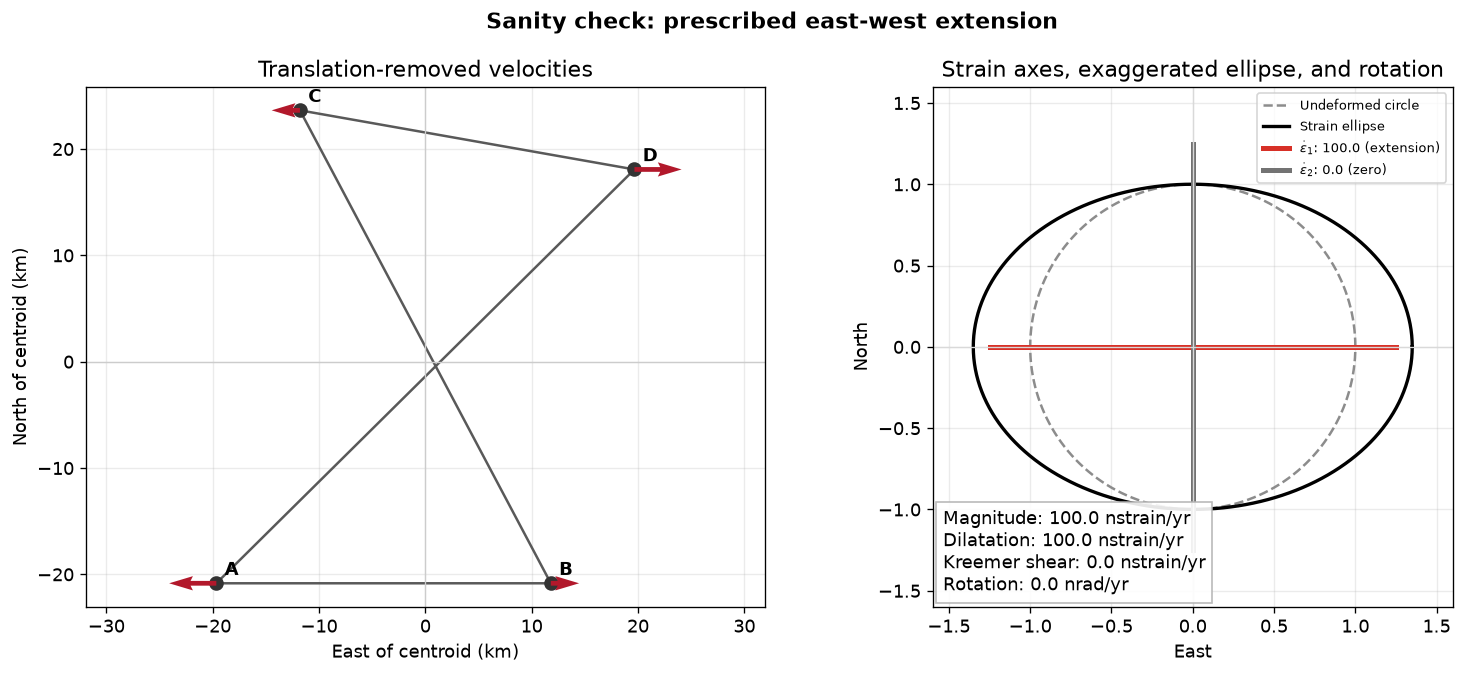

In [20]:
synthetic = pd.DataFrame({
    "stat": ["A", "B", "C", "D"],
    "lon": [-123.2, -122.8, -123.1, -122.7],
    "lat": [44.8, 44.8, 45.2, 45.15],
    "sdve": [0.1] * 4,
    "sdvn": [0.1] * 4,
})

x, y, _, _ = local_xy(synthetic.lon, synthetic.lat)

# Case 1: translation only.
synthetic["ve"] = 10.0
synthetic["vn"] = 4.0
translation_result = fit_horizontal_strain(synthetic)

# Case 2: the same translation plus 100 nstrain/yr E-W extension.
synthetic_extension = synthetic.copy()
synthetic_extension["ve"] = 10.0 + (100e-9 * x) * 1e3
extension_result = fit_horizontal_strain(synthetic_extension)

sanity_comparison = pd.DataFrame({
    "translation only": strain_summary_table(translation_result)["value"],
    "100 nstrain/yr E-W extension": strain_summary_table(extension_result)["value"],
})

display(sanity_comparison)
plot_strain_solution(
    synthetic_extension,
    extension_result,
    "Sanity check: prescribed east-west extension",
)


## Part III: PNW example

The target points below select nearby stations automatically. They form a broad triangle sampling the Cascadia forearc and the region farther inland. You will calculate one tensor averaged over this triangle and compare its magnitude and deformation style with Figure 2 of Kreemer and Young (2022).


In [21]:
def nearest_unique_stations(table, targets):
    """
    Select the nearest unused station to each target location.

    Distances are approximated in geographic coordinates with longitude
    scaled by the cosine of the target latitude. This is sufficient for
    selecting nearby stations but is not a general geodesic calculation.

    Parameters
    ----------
    table : pandas.DataFrame
        Station table containing ``lon`` and ``lat`` columns.
    targets : iterable of tuple
        Target locations as ``(longitude, latitude)`` pairs in degrees.

    Returns
    -------
    pandas.DataFrame
        Selected stations in the same order as the target locations.

    Raises
    ------
    ValueError
        If fewer unique stations are available than target locations.
    """
    chosen = []
    used = set()

    for lon_target, lat_target in targets:
        distance_squared = (
            (
                (table.lon - lon_target)
                * np.cos(np.deg2rad(lat_target))
            ) ** 2
            + (table.lat - lat_target) ** 2
        )

        available = [
            index
            for index in distance_squared.sort_values().index
            if index not in used
        ]
        if not available:
            raise ValueError(
                "Not enough unique stations to match all target locations."
            )

        chosen.append(available[0])
        used.add(available[0])

    return table.loc[chosen].copy().reset_index(drop=True)


PNW_TARGETS = [
    (-124.0, 46.2),  # coastal Washington
    (-123.1, 44.4),  # western Oregon
    (-121.6, 46.0),  # inland Washington/Oregon
]

pnw = nearest_unique_stations(velocity, PNW_TARGETS)
display(pnw)


,lon,lat,ve,vn,sdve,sdvn,ve_p,vn_p,stat,source
0,-123.956,46.205,9.40,12.64,0.14,0.12,0.77,-2.08,FTS5,#
1,-123.109,44.378,5.10,11.14,0.25,0.24,-1.91,-3.14,HLSY,#
2,-121.542,46.000,4.31,8.48,2.12,0.59,-2.32,-2.50,GS5R,$


### Inspect the selected PNW stations

The table above gives the locations, velocities, and uncertainties for the three selected stations. Before calculating, sketch the triangle and predict the directions of maximum extension and contraction from the velocity differences.


### Predict before calculating

1. Does the triangle appear to translate? In what direction?
2. Do the relative velocities suggest clockwise or counterclockwise rotation?
3. In what approximate direction do you expect maximum contraction or extension?
4. Which part of your prediction is hardest to make by eye?


Strain-rate tensor (nstrain/yr):


,East gradient,North gradient
East velocity,-25.5,-4.6
North velocity,-4.6,0.2


,value,units
quantity,,
$\dot\epsilon_{EE}$,-25.5,nstrain/yr
$\dot\epsilon_{EN}$,-4.6,nstrain/yr
$\dot\epsilon_{NN}$,0.2,nstrain/yr
"Rotation, $\omega$",-17.5,nrad/yr
"Maximum principal rate, $\dot\epsilon_1$",1.0,nstrain/yr
$\dot\epsilon_1$ azimuth,99.9,deg CCW from east
"Minimum principal rate, $\dot\epsilon_2$",-26.3,nstrain/yr
$\dot\epsilon_2$ azimuth,9.9,deg CCW from east
Tensor magnitude (Fig. 2a),26.3,nstrain/yr


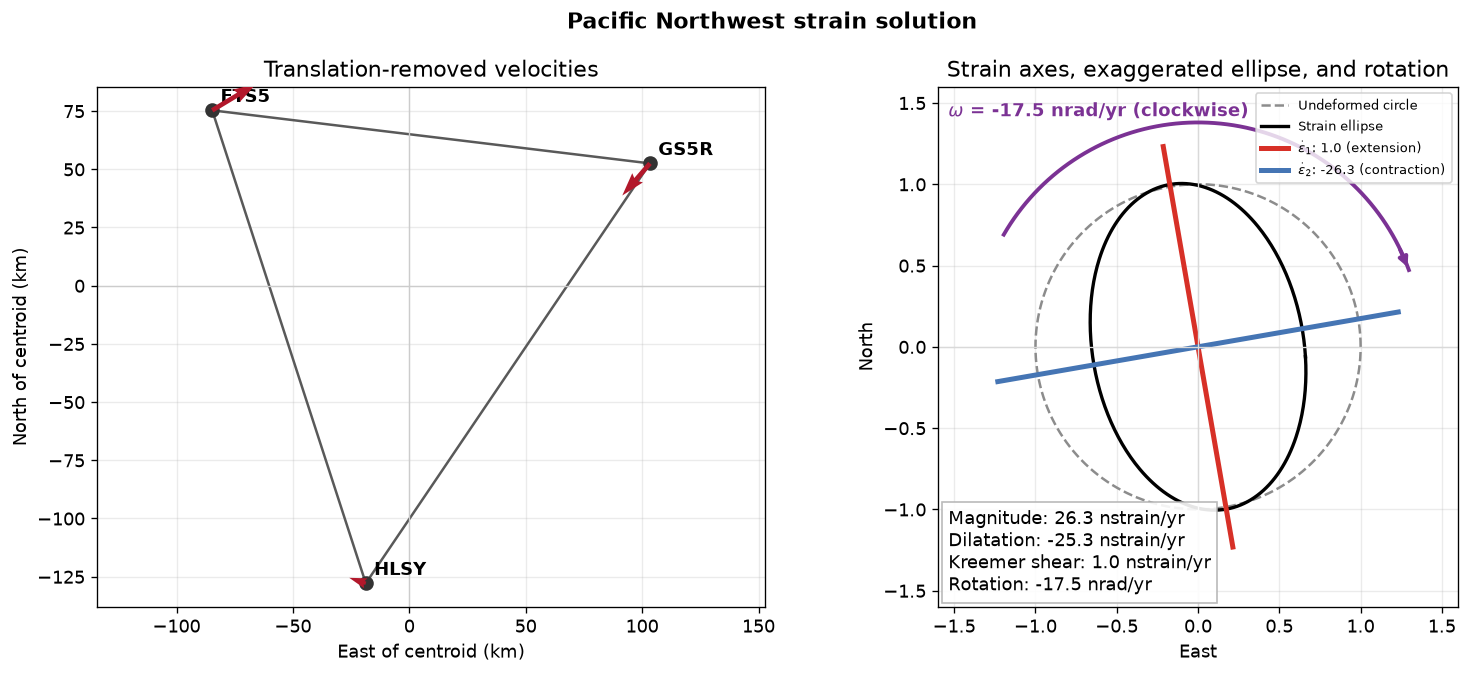

In [22]:
pnw_result = fit_horizontal_strain(
    pnw,
    VELOCITY_SCALE_TO_M_PER_YR,
)

print("Strain-rate tensor (nstrain/yr):")
display(strain_tensor_table(pnw_result))
display(strain_summary_table(pnw_result))
plot_strain_solution(
    pnw,
    pnw_result,
    "Pacific Northwest strain solution",
)


> ## **Interpret the PNW result:**
> 1. Write the numerical strain-rate tensor, including units.
> 2. Report $\dot\epsilon_1$ and $\dot\epsilon_2$, including their signs and orientations.
> 3. Is the triangle undergoing net areal expansion or contraction?
> 4. Compare the tensor magnitude, dilatation, and Kreemer shear rate with the colors near Cascadia in Figure 2.
> 5. Which principal axis is most relevant to Cascadia margin-normal shortening?
> 6. Does this triangle isolate Cascadia locking, or does it mix multiple tectonic domains?
> 7. What does an RMS residual near zero mean for a three-station solution—and what does it not mean?


## Part IV: Northern San Andreas example

Now apply exactly the same calculation and visualization near the northern San Andreas system. The targets form a triangle between the coast near the Mendocino region, the northern Coast Ranges, and the Point Reyes–San Francisco region.


In [23]:
NORCAL_TARGETS = [
    (-124.05, 40.15),
    (-122.75, 39.55),
    (-122.95, 38.15),
]

norcal = nearest_unique_stations(velocity, NORCAL_TARGETS)
display(norcal)


,lon,lat,ve,vn,sdve,sdvn,ve_p,vn_p,stat,source
0,-124.057,40.220,-17.45,30.00,0.16,0.16,2.77,-3.61,P163,#
1,-122.736,39.494,-12.25,13.31,0.19,0.18,1.26,-3.67,P334,#
2,-122.908,38.123,-22.48,34.37,0.15,0.13,-0.58,0.50,P193,#


### Your analysis

Before running the calculation, sketch or describe your expected deformation. Consider the right-lateral San Andreas system, distributed Coast Range deformation, and proximity to the Mendocino Triple Junction.


Strain-rate tensor (nstrain/yr):


,East gradient,North gradient
East velocity,87.4,-85.2
North velocity,-85.2,-115.9


,value,units
quantity,,
$\dot\epsilon_{EE}$,87.4,nstrain/yr
$\dot\epsilon_{EN}$,-85.2,nstrain/yr
$\dot\epsilon_{NN}$,-115.9,nstrain/yr
"Rotation, $\omega$",-143.8,nrad/yr
"Maximum principal rate, $\dot\epsilon_1$",118.4,nstrain/yr
$\dot\epsilon_1$ azimuth,160.0,deg CCW from east
"Minimum principal rate, $\dot\epsilon_2$",-146.9,nstrain/yr
$\dot\epsilon_2$ azimuth,70.0,deg CCW from east
Tensor magnitude (Fig. 2a),188.7,nstrain/yr


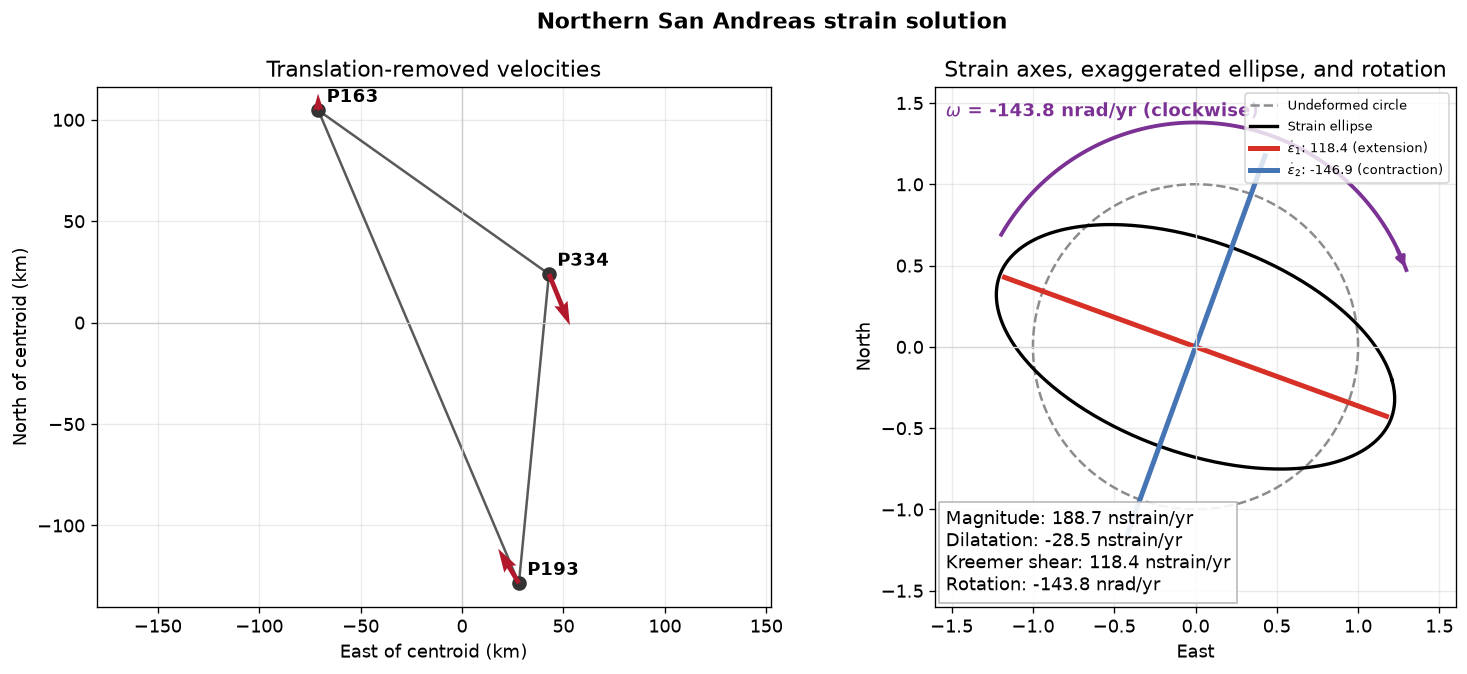

In [24]:
norcal_result = fit_horizontal_strain(
    norcal,
    VELOCITY_SCALE_TO_M_PER_YR,
)

print("Strain-rate tensor (nstrain/yr):")
display(strain_tensor_table(norcal_result))
display(strain_summary_table(norcal_result))
plot_strain_solution(
    norcal,
    norcal_result,
    "Northern San Andreas strain solution",
)


> ## **Interpret northern California:**
> 1. Is rotation clockwise or counterclockwise? Is that consistent with the map?
> 2. What are the orientations of maximum extension and maximum contraction?
> 3. Would a right-lateral fault produce principal axes parallel and perpendicular to the fault, or oblique to it?
> 4. Does the result appear dominated by strike-slip shear, extension, contraction, or a combination?
> 5. Which known tectonic structures fall inside the triangle?
> 6. What additional information would you want before assigning the strain to one fault?

## Part V: Compare the Two Tectonic Settings

The next table and plot place the PNW and northern San Andreas results on the same numerical scale. These triangle estimates should be compared with the **sign, deformation style, and approximate magnitude** in Kreemer and Young's Figure 2—not with the value of an individual map pixel, because their regional field is spatially smoothed.


,PNW,Northern San Andreas
Tensor magnitude,26.3,188.7
Dilatation,-25.3,-28.5
Kreemer shear,1.0,118.4


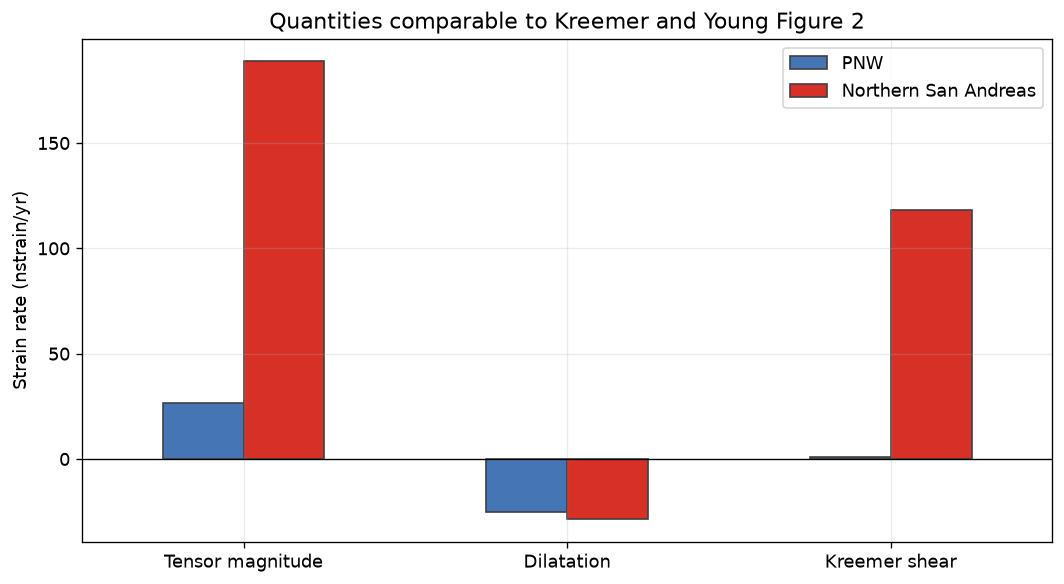

In [25]:
comparison_quantities = {
    "Tensor magnitude": "tensor_magnitude_nstrain_yr",
    "Dilatation": "dilatation_nstrain_yr",
    "Kreemer shear": "kreemer_shear_nstrain_yr",
}

tectonic_comparison = pd.DataFrame({
    "PNW": {
        label: pnw_result[key]
        for label, key in comparison_quantities.items()
    },
    "Northern San Andreas": {
        label: norcal_result[key]
        for label, key in comparison_quantities.items()
    },
})

display(tectonic_comparison.round(1))

ax = tectonic_comparison.plot.bar(
    figsize=(9, 5),
    color=["#4575b4", "#d73027"],
    edgecolor="0.25",
)
ax.axhline(0, color="k", linewidth=0.8)
ax.set(
    ylabel="Strain rate (nstrain/yr)",
    title="Quantities comparable to Kreemer and Young Figure 2",
)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## Part VI: Sensitivity to Station Geometry

A three-station strain estimate is specific to its selected triangle. Move one target by roughly 0.5–1° or replace one station, then recompute both the numerical tensor and the visualization.


,lon,lat,ve,vn,sdve,sdvn,ve_p,vn_p,stat,source
0,-123.906,40.024,-21.70,29.97,0.19,0.18,1.78,-3.91,P156,#
1,-122.736,39.494,-12.25,13.31,0.19,0.18,1.26,-3.67,P334,#
2,-122.908,38.123,-22.48,34.37,0.15,0.13,-0.58,0.50,P193,#


,original triangle,alternative triangle
quantity,,
$\dot\epsilon_{EE}$,87.4,125.8
$\dot\epsilon_{EN}$,-85.2,-89.0
$\dot\epsilon_{NN}$,-115.9,-115.5
"Rotation, $\omega$",-143.8,-143.8
"Maximum principal rate, $\dot\epsilon_1$",118.4,155.1
$\dot\epsilon_1$ azimuth,160.0,161.8
"Minimum principal rate, $\dot\epsilon_2$",-146.9,-144.8
$\dot\epsilon_2$ azimuth,70.0,71.8
Tensor magnitude (Fig. 2a),188.7,212.2


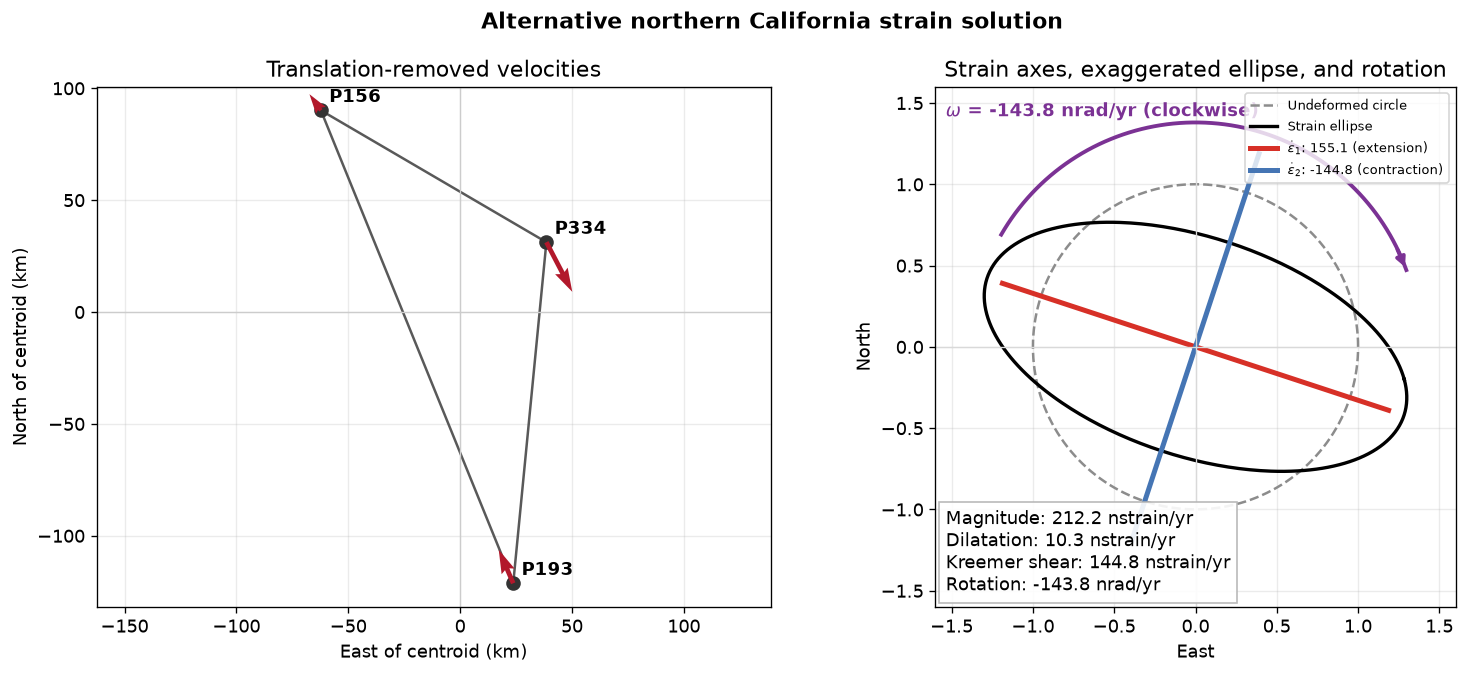

In [26]:
NORCAL_ALTERNATIVE_TARGETS = [
    (-123.75, 40.00),
    (-122.75, 39.55),
    (-122.95, 38.15),
]

norcal_alternative = nearest_unique_stations(
    velocity,
    NORCAL_ALTERNATIVE_TARGETS,
)
alternative_result = fit_horizontal_strain(
    norcal_alternative,
    VELOCITY_SCALE_TO_M_PER_YR,
)

geometry_comparison = pd.DataFrame({
    "original triangle": strain_summary_table(norcal_result)["value"],
    "alternative triangle": strain_summary_table(alternative_result)["value"],
})

display(norcal_alternative)
display(geometry_comparison)
plot_strain_solution(
    norcal_alternative,
    alternative_result,
    "Alternative northern California strain solution",
)


> ## **Evaluate sensitivity:**
> 1. Which result changed most: translation, rotation, principal strain magnitude, or principal-axis orientation?
> 2. Did the sign of either principal strain change?
> 3. Which tectonic boundary or velocity gradient was added to or removed from the triangle?
> 4. Which interpretation is robust to the station change?
> 5. Write one sentence explaining why a published strain-rate map should not be interpreted without knowing its spatial smoothing or station geometry.

## Part VII: Optional Extension Using More Stations

The function also accepts additional stations and solves an overdetermined weighted least-squares problem. Select all stations in a compact bounding box and compare the resulting tensor with the three-station estimate spanning the same region.


Regional solution uses 105 stations


,value,units
quantity,,
$\dot\epsilon_{EE}$,114.4,nstrain/yr
$\dot\epsilon_{EN}$,-64.9,nstrain/yr
$\dot\epsilon_{NN}$,-116.1,nstrain/yr
"Rotation, $\omega$",-113.1,nrad/yr
"Maximum principal rate, $\dot\epsilon_1$",131.4,nstrain/yr
$\dot\epsilon_1$ azimuth,165.3,deg CCW from east
"Minimum principal rate, $\dot\epsilon_2$",-133.1,nstrain/yr
$\dot\epsilon_2$ azimuth,75.3,deg CCW from east
Tensor magnitude (Fig. 2a),187.1,nstrain/yr


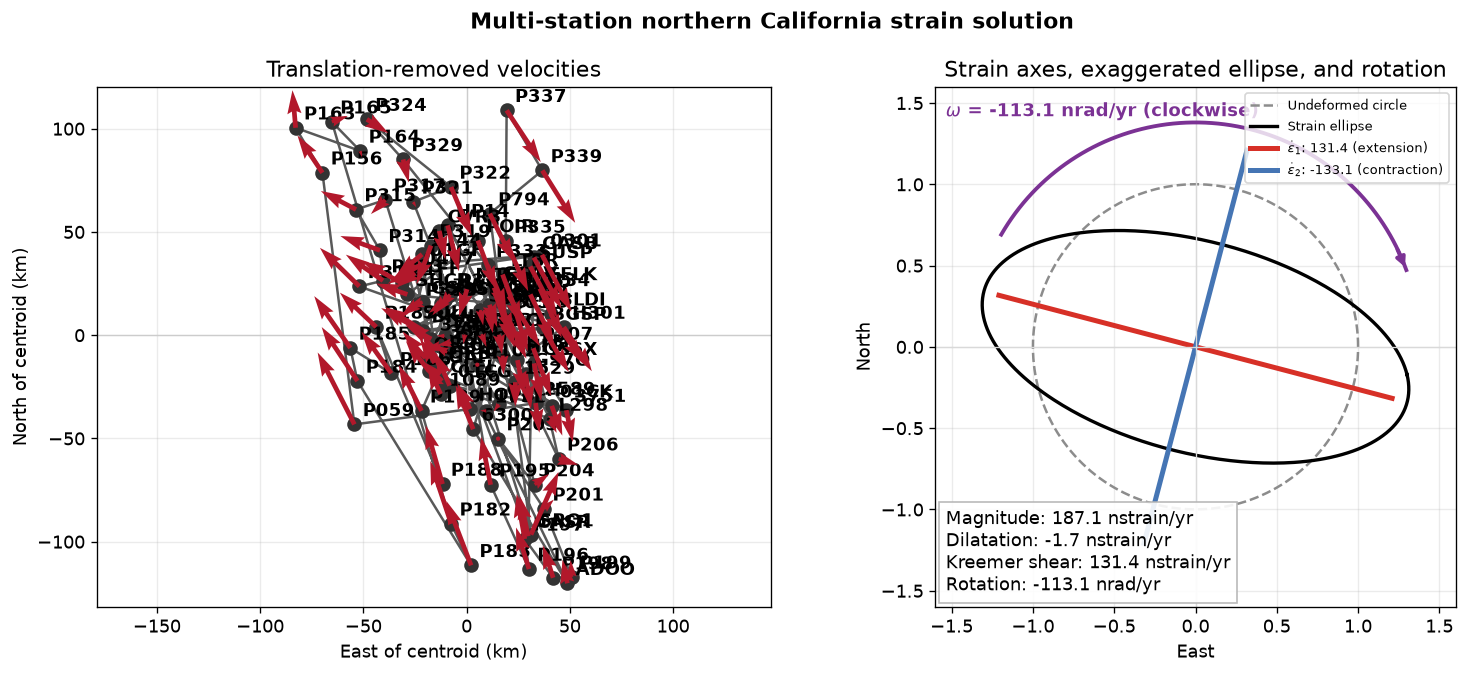

In [27]:
regional = velocity[
    velocity.lon.between(-124.2, -122.5)
    & velocity.lat.between(38.2, 40.3)
].copy()

print(f"Regional solution uses {len(regional)} stations")
if len(regional) >= 4:
    regional_result = fit_horizontal_strain(
        regional,
        VELOCITY_SCALE_TO_M_PER_YR,
    )
    display(strain_summary_table(regional_result))
    plot_strain_solution(
        regional,
        regional_result,
        "Multi-station northern California strain solution",
    )
else:
    print("Fewer than four stations found; expand the bounding box.")


---
## Synthesis

> **In a short paragraph, compare the PNW and northern California results. Your response should:**
> 1. write or describe each strain-rate tensor;
> 2. compare the principal strain rates and their orientations;
> 3. compare tensor magnitude, dilatation, and Kreemer shear rate with Figure 2;
> 4. connect each deformation style to its regional plate boundary; and
> 5. describe at least one limitation caused by station geometry or spatial scale.

**References**
- Kreemer, C., and Young, Z. M. (2022), *Crustal Strain Rates in the Western United States and Their Relationship with Earthquake Rates*, **Seismological Research Letters**, 93, 2990–3008. https://doi.org/10.1785/0220220153
- Kreemer and Young velocity dataset: https://doi.org/10.7910/DVN/BICMWB
- GETSI/EarthScope, *Infinitesimal Strain Analysis Using GPS Data*.
- Savage et al. (2001), method underlying the GETSI `calcstrain.m` implementation.


---

## Summary

- A GNSS velocity describes one station's motion; strain rate describes how velocity changes spatially.
- A local velocity field can be separated into translation, rigid-body rotation, and a symmetric strain-rate tensor.
- The tensor components $\dot\epsilon_{EE}$, $\dot\epsilon_{EN}$, and $\dot\epsilon_{NN}$ quantitatively describe horizontal deformation.
- The tensor's eigenvalues and eigenvectors give the principal strain rates and their orientations.
- Tensor magnitude, dilatation, and the Kreemer shear rate connect a local calculation to panels (a)–(c) of Kreemer and Young's Figure 2.
- Three-station solutions are exactly determined and strongly dependent on station geometry and spatial scale.
- Triangle results should be compared with the regional map by sign, deformation style, and approximate magnitude rather than exact pixel value.

This notebook was adapted for EPS 166 from GETSI/EarthScope teaching materials and the western U.S. GNSS velocity field of Kreemer and Young (2022).
